# install

In [1]:
# Cài đặt hoặc nâng cấp vnstock
!pip install -U vnstock

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.7/278.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.4 MB/s eta 0:00:00


In [2]:
from vnstock import Quote
quote = Quote(symbol='ACB', source='KBS')


📋 Connecting Google Drive account
to save project settings.



ERROR:vnstock.core.config.ggcolab:Error mounting Drive: Error: credential propagation was unsuccessful


In [3]:
# Khung thời gian ngày: 1D hay d cho interval
df = quote.history(start='2024-01-01', end='2025-11-10', interval='d')
df
# quote.history(symbol='VNINDEX', start='2024-01-02', end='2025-11-10', interval='1D')quote.history(symbol='VNINDEX', start='2024-01-02', end='2025-11-10', interval='1D')

,time,open,high,low,close,volume
0,2024-01-02 07:00:00,14.50,14.98,14.50,14.80,13883500
1,2024-01-03 07:00:00,14.83,15.13,14.68,15.13,9803400
2,2024-01-04 07:00:00,15.25,15.53,15.19,15.32,23587800
3,2024-01-05 07:00:00,15.32,15.41,15.16,15.41,9272100
4,2024-01-08 07:00:00,15.56,15.59,15.25,15.34,12389600
...,...,...,...,...,...,...
457,2025-11-04 07:00:00,21.94,22.50,21.90,22.42,17972000
458,2025-11-05 07:00:00,22.25,22.33,22.03,22.07,6212200
459,2025-11-06 07:00:00,22.03,22.16,21.82,21.82,6525200
460,2025-11-07 07:00:00,21.77,21.82,21.43,21.47,12107200


# Cell 1: Tính return + thống kê mô tả

In [4]:
import numpy as np
import pandas as pd

df = df.copy()

df = df.assign(
    simple_return=lambda x: x["close"].pct_change(),
    log_return=lambda x: np.log(x["close"] / x["close"].shift(1))
).dropna()

stats_df = (
    df[["simple_return", "log_return"]]
    .agg(["mean", "std", "var", "skew", "kurt"])
    .rename(index={"var": "variance", "skew": "skewness", "kurt": "kurtosis"})
    .round(6)
)

stats_df

,simple_return,log_return
mean,0.000900,0.000798
std,0.014268,0.014246
variance,0.000204,0.000203
skewness,0.221175,0.024187
kurtosis,7.280555,7.339729


Simple return : 0.001089

Log return    : 0.000992

≈ 0.10%/phiên

Nếu quy đổi theo khoảng 252 phiên/năm => 0.0992%×252 ≈  25% => Hợp lý cho 1 cp bank như ACB

Std = 0.01396

≈ 1.4%/ngày

Annualized volatility σ_year =0.01396×căn bậc hai (252) ≈ 22%

Độ nhọn: 0.003364 => gần như đối xứng hoàn toàn

=> Xác suất tăng giảm gần như tương đương nhau trong giai đoạn này

Kurtosis ≈ 7.6

So với Kurtosis = 3 của PP chuẩn (normal) thì 7.6 là rất cao => cả 2 loại return đều có fat tail

# Cell 2: Chuẩn bị tham số Monte Carlo

In [5]:
np.random.seed(42)

N_DAYS, N_SIMS = 252, 1000

last_price = df["close"].iloc[-1]
mu, sigma = df["log_return"].mean(), df["log_return"].std()

# Cell 3: Monte Carlo simulation (vectorized)

In [6]:
rand = np.random.normal(mu, sigma, (N_DAYS, N_SIMS))
# đây là Empirical GBM (tức là giả định giá tuân theo GBM và ước lượng tham số cho GBM là μ và σ dựa vào lịch sử)

paths = last_price * np.exp(np.cumsum(rand, axis=0)) # np.cumsum(rand, axis=0) đây là log return => dùng np.exp để chuyển về price thuần, rồi nhân với S0

mean_path = paths.mean(axis=1)
lower = np.percentile(paths, 2.5, axis=1)
upper = np.percentile(paths, 97.5, axis=1)

# Cell 4: Plot Monte Carlo

In [7]:
import plotly.graph_objects as go

COLORS = {
    "bg": "#ffffff",
    "text": "#2b3d6f",
    "main": "#5b6fa2",
    "secondary": "#8e99ad",
    "accent": "#fea7e9",
}

fig = go.Figure()

# paths (efficient)
fig.add_traces([
    go.Scatter(
        y=paths[:, i],
        line=dict(color=COLORS["secondary"], width=0.5),
        opacity=0.15,
        showlegend=False
    )
    for i in range(N_SIMS)
])

# mean
fig.add_trace(go.Scatter(
    y=mean_path,
    name="Mean",
    line=dict(color=COLORS["main"], width=3)
))

# CI
fig.add_trace(go.Scatter(
    y=upper,
    line=dict(color=COLORS["accent"], dash="dot"),
    name="95% CI Upper"
))

fig.add_trace(go.Scatter(
    y=lower,
    fill="tonexty",
    line=dict(color=COLORS["accent"], dash="dot"),
    name="95% CI Lower"
))

fig.update_layout(
    title="Monte Carlo Simulation (GBM)",
    plot_bgcolor=COLORS["bg"],
    paper_bgcolor=COLORS["bg"],
    font=dict(color=COLORS["text"]),
    xaxis_title="Time",
    yaxis_title="Price"
)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

# Cell 5: Histogram + Normal Distribution

In [8]:
from scipy import stats
import plotly.graph_objects as go

log_ret = df["log_return"]

x = np.linspace(log_ret.min(), log_ret.max(), 300)
pdf = stats.norm.pdf(x, log_ret.mean(), log_ret.std())

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=log_ret,
    nbinsx=50,
    histnorm="probability density",
    marker_color=COLORS["main"],
    name="Log Return"
))

fig.add_trace(go.Scatter(
    x=x,
    y=pdf,
    line=dict(color=COLORS["accent"], width=3),
    name="Normal PDF"
))

fig.add_annotation(
    xref="paper", yref="paper",
    x=0.95, y=0.95,
    text=f"μ={log_ret.mean():.4f}<br>σ={log_ret.std():.4f}",
    showarrow=False,
    font=dict(color=COLORS["text"])
)

fig.update_layout(
    title="Log Return Distribution vs Normal",
    plot_bgcolor=COLORS["bg"],
    paper_bgcolor=COLORS["bg"],
    font=dict(color=COLORS["text"])
)

fig.show()

Hình dạng gần như phân phối chuẩn, nhưng có đuôi dày

# Cell 6: QQ Plot

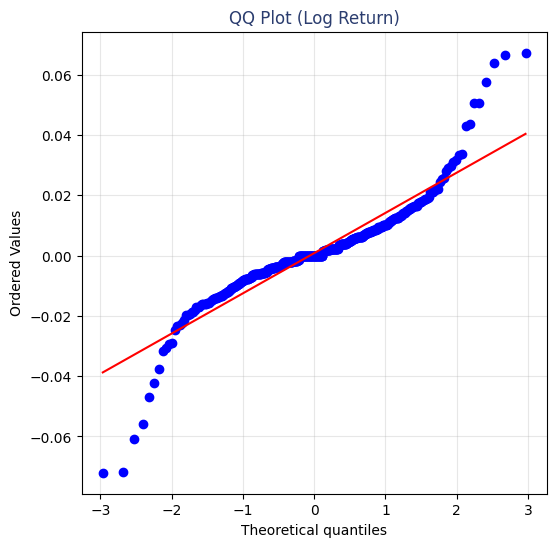

In [9]:
import matplotlib.pyplot as plt
from scipy import stats

plt.figure(figsize=(6, 6))
stats.probplot(log_ret, dist="norm", plot=plt)

plt.title("QQ Plot (Log Return)", color=COLORS["text"])
plt.grid(alpha=0.3)

plt.show()

Hình dạng chứng minh log_return có fat-tail. Đây là hình dạng tiêu biểu, với 2 đuôi bị lệch xa khỏi đường trung bình

# Cell 7: Kolmogorov–Smirnov Test

In [10]:
ks_stat, p_value = stats.kstest(
    log_ret,
    "norm",
    args=(log_ret.mean(), log_ret.std())
)

ks_result = pd.DataFrame({
    "KS Statistic": [ks_stat],
    "p-value": [p_value],
    "Conclusion (5%)": ["Reject H0" if p_value < 0.05 else "Fail to Reject H0"]
})

ks_result

,KS Statistic,p-value,Conclusion (5%)
0,0.113795,0.000012,Reject H0


Phân phối của Log_return không chuẩn, vì KS test bác bỏ giả thuyết H0

In [11]:
summary = f"""
1. Return KHÔNG hoàn toàn tuân theo phân phối chuẩn:
   - QQ plot lệch ở tail
   - KS test thường reject H0

2. Fat-tail:
   - Có (kurtosis > 0)

3. Skew:
   - Có thể lệch nhẹ (skew ≠ 0)

4. Monte Carlo dùng Normal:
   - KHÔNG hoàn toàn phù hợp (underestimate risk)

5. Mô hình tốt hơn:
   - Geometric Brownian Motion (cơ bản)
   - Student-t (fat-tail)
   - Bootstrap / Historical Simulation
   - GARCH (volatility clustering)
"""

print(summary)


1. Return KHÔNG hoàn toàn tuân theo phân phối chuẩn:
   - QQ plot lệch ở tail
   - KS test thường reject H0

2. Fat-tail:
   - Có (kurtosis > 0)

3. Skew:
   - Có thể lệch nhẹ (skew ≠ 0)

4. Monte Carlo dùng Normal:
   - KHÔNG hoàn toàn phù hợp (underestimate risk)

5. Mô hình tốt hơn:
   - Geometric Brownian Motion (cơ bản)
   - Student-t (fat-tail)
   - Bootstrap / Historical Simulation
   - GARCH (volatility clustering)



# Cell 8: Overlay Monte Carlo vs giá thật ACB

In [12]:
# align length (lấy đoạn cuối của data thật để so với simulation)
real_prices = df["close"].iloc[-N_DAYS:].values

import plotly.graph_objects as go

fig = go.Figure()

# simulated paths (vẽ mờ)
fig.add_traces([
    go.Scatter(
        y=paths[:, i],
        line=dict(width=0.5),
        opacity=0.1,
        showlegend=False
    )
    for i in range(N_SIMS)
])

# mean simulation
fig.add_trace(go.Scatter(
    y=mean_path,
    name="Monte Carlo Mean",
    line=dict(width=3)
))

# real price (ACB)
fig.add_trace(go.Scatter(
    y=real_prices,
    name="ACB Real Price",
    line=dict(width=3, dash="dash")
))

fig.update_layout(
    title="Monte Carlo vs Real Price (ACB)",
    xaxis_title="Time",
    yaxis_title="Price"
)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

GBM liên tục đánh giá cao xu hướng tăng của ACB, trong khi giá thực tế liên tục nằm dưới đường trung bình

Độ phân tán của mô phỏng lớn nhưng chưa phản ánh đúng chế độ thị trường

=> Đang đánh giá quá lạc quan

**Nguyên nhân**: có thể các tham số được ước lượng từ dữ liệu chưa hợp lý, dữ liệu không phù hợp với các giả định của GBM

# Cell 9: Tính return sau N ngày từ simulation

In [13]:
# return cuối kỳ của mỗi path
final_prices = paths[-1, :]

sim_returns = (final_prices - last_price) / last_price

# Cell 10: Tính VaR (5%)

In [14]:
VaR_5 = np.percentile(sim_returns, 5)

VaR_df = pd.DataFrame({
    "Metric": ["VaR 5%"],
    "Value": [VaR_5]
})

VaR_df

,Metric,Value
0,VaR 5%,-0.155837


Với độ tin cậy 95%, mức lỗ tối đa của cổ phiếu ACB trong khoảng thời gian đang xét là 10.7%

Tuy nhiên, GBM có thể bị đánh giá sai lệch (dựa vào kết quả bên trên), kết quả này có thể chưa thể phản ánh đúng rủi ro đuôi ở thực tế

# Cell 11: Visualize phân phối return + VaR

In [15]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=sim_returns,
    nbinsx=50,
    histnorm="probability density",
    name="Simulated Returns"
))

fig.add_vline(
    x=VaR_5,
    line_dash="dash",
    annotation_text=f"VaR 5% = {VaR_5:.2%}",
    annotation_position="top left"
)

fig.update_layout(
    title="Distribution of Simulated Returns & VaR",
    xaxis_title="Return",
    yaxis_title="Density"
)

fig.show()

Phân phối bị lệch phải, với đuôi bên phải dài (return cao tới 1.4 ≈ 140%) trong khi đuôi bên trái ngắn hơn đáng kể (≈ -40%)

Mức VaR là -10.7% tương đối cao cho một cổ phiếu bank như ACB

Có thể thấy GBM đang quá lạc quan và đánh giá thấp rủi ro khi thị trường đi xuống